In [20]:
import numpy as np
from scipy.io import wavfile
from sklearn.decomposition import FastICA
import matplotlib.pyplot as plt

In [10]:
rate1, mic1 = wavfile.read("../../data/ICA/ICA mix 1.wav")
rate2, mic2 = wavfile.read("../../data/ICA/ICA mix 2.wav")
rate3, mic3 = wavfile.read("../../data/ICA/ICA mix 3.wav")

In [11]:
mic1 = mic1.astype(np.float64)
mic2 = mic2.astype(np.float64)
mic3 = mic3.astype(np.float64)

In [12]:
n = min(len(mic1), len(mic2), len(mic3))

mic1 = mic1[:n]
mic2 = mic2[:n]
mic3 = mic3[:n]

In [13]:
X = np.column_stack([
    mic1,
    mic2,
    mic3
])

print(X.shape)

(264515, 3)


In [14]:
X = X - X.mean(axis=0)

In [15]:
ica = FastICA(
    n_components=3,
    whiten="unit-variance",
    random_state=0,
    max_iter=5000
)

S = ica.fit_transform(X)

In [16]:
A = ica.mixing_
print(A)

[[-2490.20687863 -3659.07913815  3563.32937715]
 [ -226.96641911 -3670.56540164  8231.5147482 ]
 [-2083.72665878 -3635.67656457 18346.72102458]]


In [17]:
W = ica.components_
print(W)

[[-3.21485305e-04  4.65502447e-04 -1.46414840e-04]
 [-1.11597368e-04 -3.28757894e-04  1.69176477e-04]
 [-5.86273392e-05 -1.22788979e-05  7.14014481e-05]]


In [18]:
for i in range(3):
    S[:, i] = S[:, i] / np.max(np.abs(S[:, i]))

In [19]:
wavfile.write(
    "source1.wav",
    rate1,
    (S[:, 0] * 32767).astype(np.int16)
)

wavfile.write(
    "source2.wav",
    rate1,
    (S[:, 1] * 32767).astype(np.int16)
)

wavfile.write(
    "source3.wav",
    rate1,
    (S[:, 2] * 32767).astype(np.int16)
)

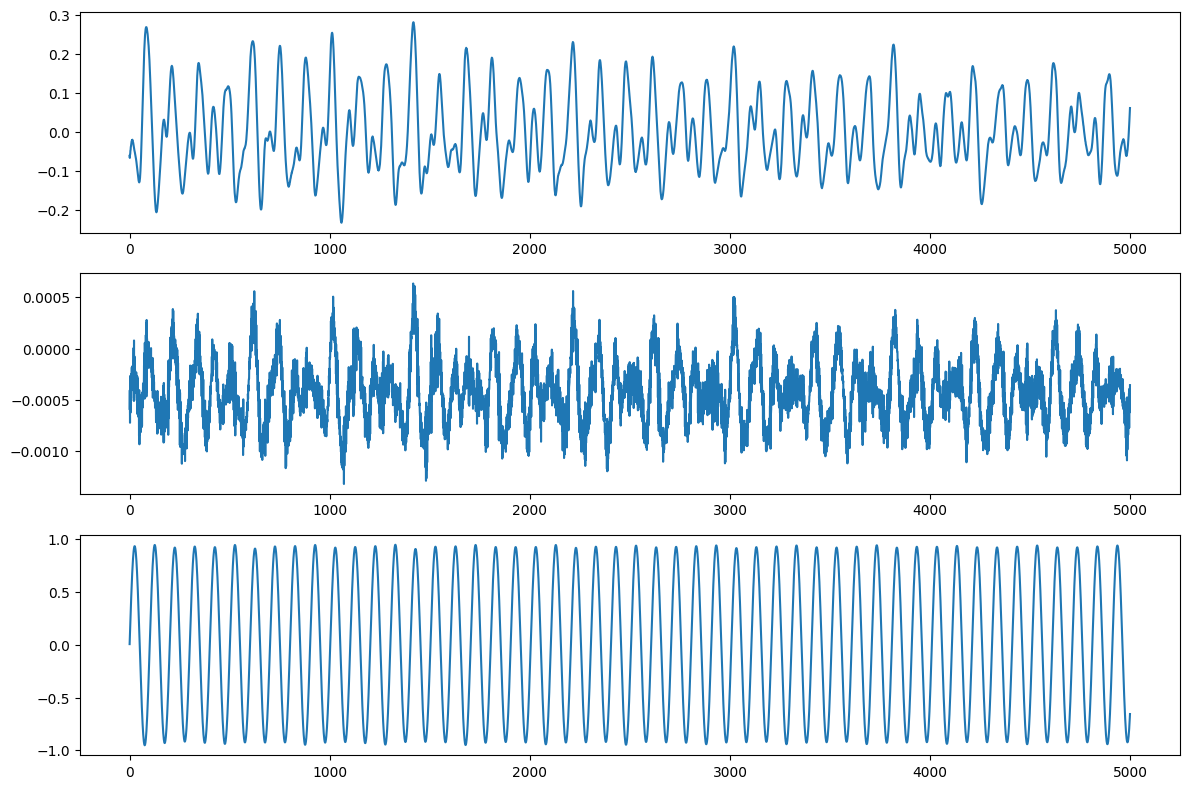

In [21]:
plt.figure(figsize=(12,8))

for i in range(3):
    plt.subplot(3,1,i+1)
    plt.plot(S[:5000, i])

plt.tight_layout()
plt.show()